In [2]:
import math
import time
import random
import numpy as np
import pandas as pd
import json
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp
from bessel_zeros import get_bessel_zeros
from scipy.special import jv, jvp, gamma, loggamma
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import matplotlib.patches as patches
font = font_manager.FontProperties(style='normal', size=20)
import seaborn as sns
import matplotlib.ticker as ticker
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

from bessel_zeros import get_bessel_zeros
from CDFs import build_cdfs as build_cdfs
import seaborn as sns

In [3]:
# from pathlib import Path
import os
# path = Path.cwd()
path = os.getcwd() #'/Users/arashfahim/Documents/GitHub/Power_Series_Stochastic_Modeling/Tests'

print(os.getcwd())

/Users/arashfahim/Documents/GitHub/Power_Series_Stochastic_Modeling/Tests


In [4]:
def avg_length(d):
        path_length_woc = path + f"/outputs/d{d}/path_length_WoC_{d}.json"
        with open(path_length_woc, 'r') as json_file:
                # Use json.load() to convert the file content into a Python dictionary
                length_dict_woc = json.load(json_file)
        path_p_exit = path + f"/outputs/d{d}/p_exit_{d}.json"
        with open(path_p_exit, 'r') as json_file:
                # Use json.load() to convert the file content into a Python dictionary
                p_dict = json.load(json_file)       
        path_length_wohb = path + f"/outputs/d{d}/path_length_WoHB_{d}.json"          
        with open(path_length_wohb, 'r') as json_file:
                # Use json.load() to convert the file content into a Python dictionary
                length_dict_wohb = json.load(json_file)    
                # p_surv = [v for k, v in p_dict.items()]
        avg_length_woc = np.array([[p_dict[s], np.mean(length)] for s, length in length_dict_woc.items()])
        avg_length_wohb = np.mean(length_dict_wohb['wohb'])
        return avg_length_woc.astype(float), avg_length_wohb, p_dict

In [5]:
avg_woc = {}
avg_wohb = {}
p_dict = {}
dims = [2,10,50,100]
for i,d in enumerate(dims):
    tmp = avg_length(d)
    avg_woc[d] = tmp[0]
    avg_wohb[d] = tmp[1]
    p_dict[d] = tmp[2]
    
vals = [v for k,v in avg_wohb.items()]
p_dict

{2: {'0.005': 9.43689570931383e-15,
  '0.13': 0.04043932263568617,
  '0.255': 0.2554689038177044,
  '0.38': 0.46936858093241096,
  '0.505': 0.6285430885287833,
  '0.63': 0.7409528825753232,
  '0.755': 0.819491106039675,
  '0.88': 0.8742396923933475,
  '1.0050000000000001': 0.9123861873101011,
  '1.1300000000000001': 0.9389623014680308,
  '1.2550000000000001': 0.9574770888425037,
  '1.3800000000000001': 0.9703757289923222},
 10: {'0.005': 2.9058977446538847e-12,
  '0.015': 3.6369762757004764e-10,
  '0.025': 3.0289381066528343e-05,
  '0.035': 0.00249957433813619,
  '0.045': 0.02295665480479414,
  '0.055': 0.08167692397698167,
  '0.065': 0.17916261591182825,
  '0.075': 0.29889705606492034,
  '0.085': 0.42226991946075565,
  '0.095': 0.5364520118566389,
  '0.105': 0.6351678371739453,
  '0.115': 0.7167952086707358,
  '0.125': 0.7823118498162022,
  '0.135': 0.8338421711055136,
  '0.145': 0.8738086855479023,
  '0.155': 0.9045051653204358,
  '0.165': 0.9279202880137547,
  '0.17500000000000002':

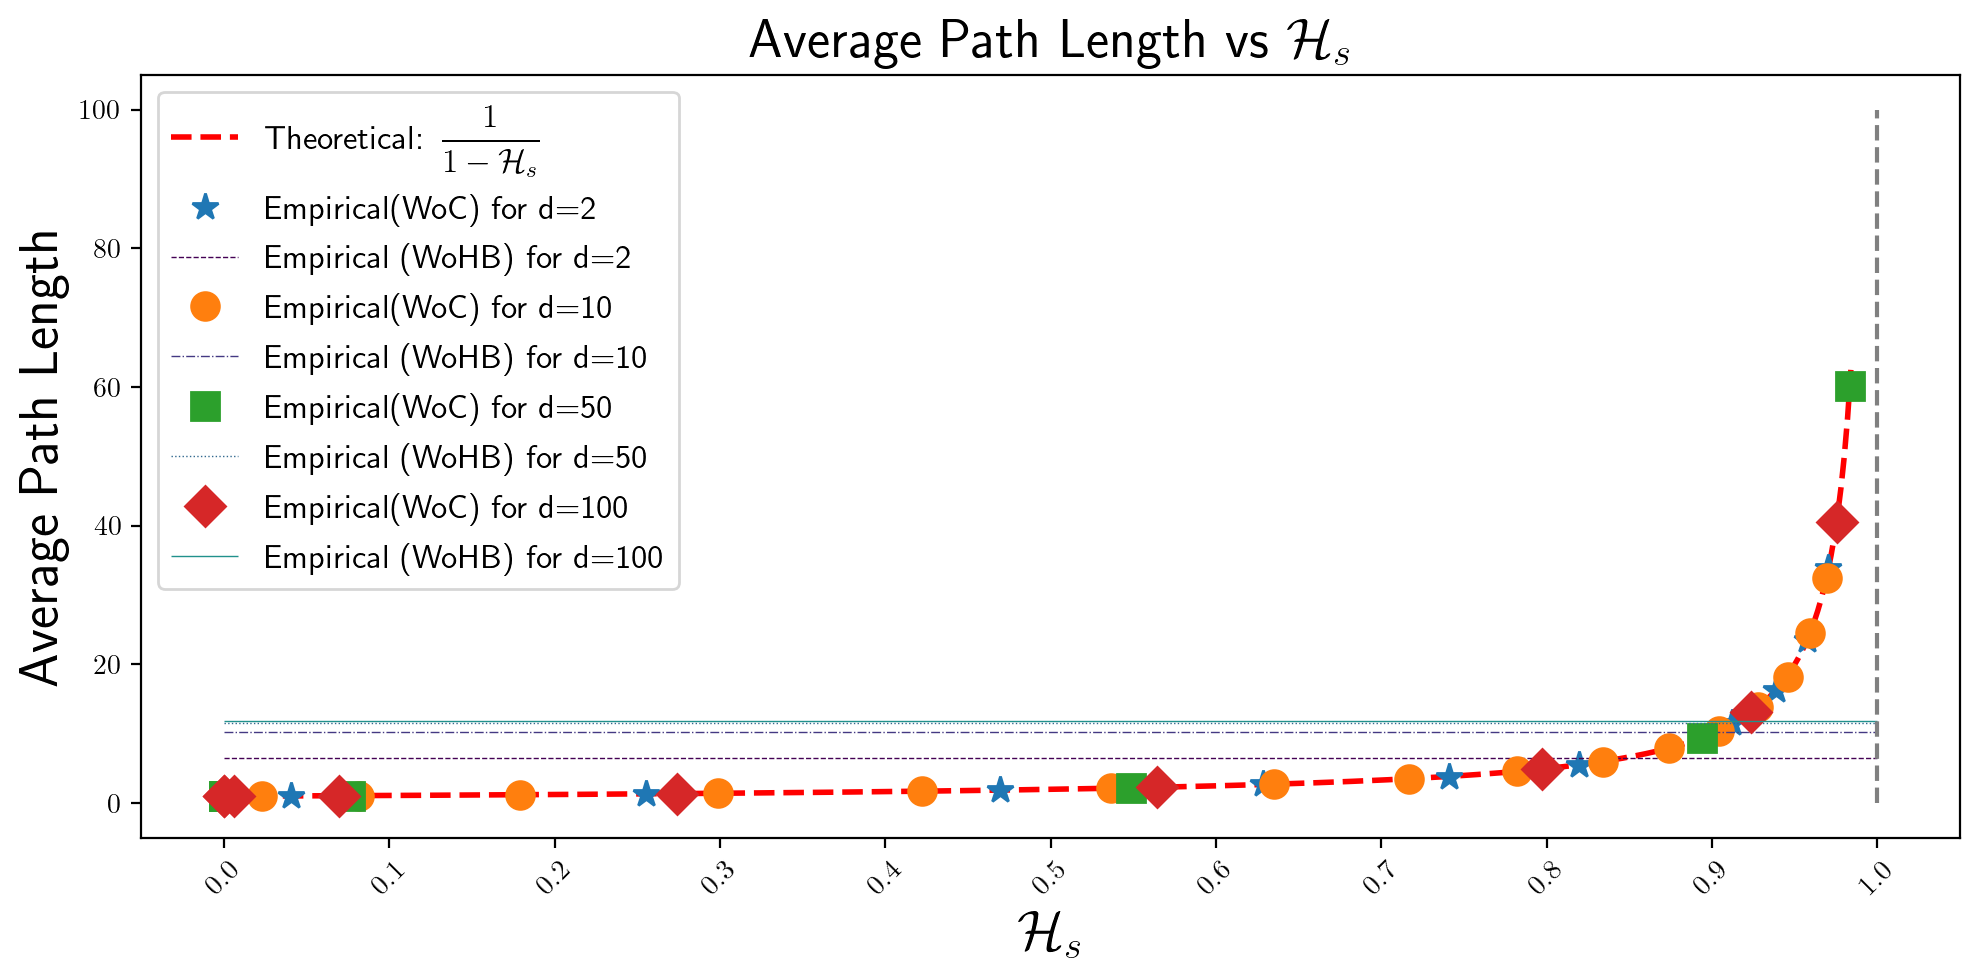

In [6]:
# ── PLOTTING ────────────────────────────────────────────────────────────────
f , ax = plt.subplots(1,1,figsize=(10, 5),dpi=200)
r = np.arange(0.,0.986,0.002)
colors = plt.cm.viridis(np.linspace(0, 0.5, len(dims)))
marks = ['*', 'o', 's', 'D']
linestyles = ['--', '-.', ':', '-']
ax.plot(r, (1/(1-np.array(r))), linewidth=2, linestyle='--', color='red', label=r'Theoretical: $\dfrac{1}{1-\mathcal{H}_s}$')
for d in dims:
    ax.plot(avg_woc[d][:,0], avg_woc[d][:,1],  marker=marks[dims.index(d)], markersize=10, linewidth=0, label=f'Empirical(WoC) for d={d}')
    ax.hlines(vals[dims.index(d)], xmin=0, xmax=1, linewidth=.5, linestyles=linestyles[dims.index(d)], color = colors[dims.index(d)], label=f'Empirical (WoHB) for d={d}')


plt.xlabel(r'$\mathcal{{H}}_s$', fontproperties=font)
plt.ylabel('Average Path Length', fontproperties=font)
plt.title(r'Average Path Length vs $\mathcal{{H}}_s$', fontproperties=font)
ax.set_xticks(np.arange(0.,1.1,0.1))
plt.vlines(1,ymin=0,ymax=100, colors='grey', linestyles='dashed')
plt.xticks(rotation=45);
# # plt.yscale('log');
# # plt.xscale('log');
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
ax.legend(prop={'size': 'large'}, loc='upper left', bbox_to_anchor=(0, 1))
plt.tight_layout();
# plt.show()
f.savefig(f'avg_path_length_vs_dim.pdf',format="pdf",dpi=600)

In [7]:
H_s = {}
for i,d in enumerate(dims):    
    H_s[d] = np.array([[float(s),float(h)] for s, h in p_dict[d].items()])

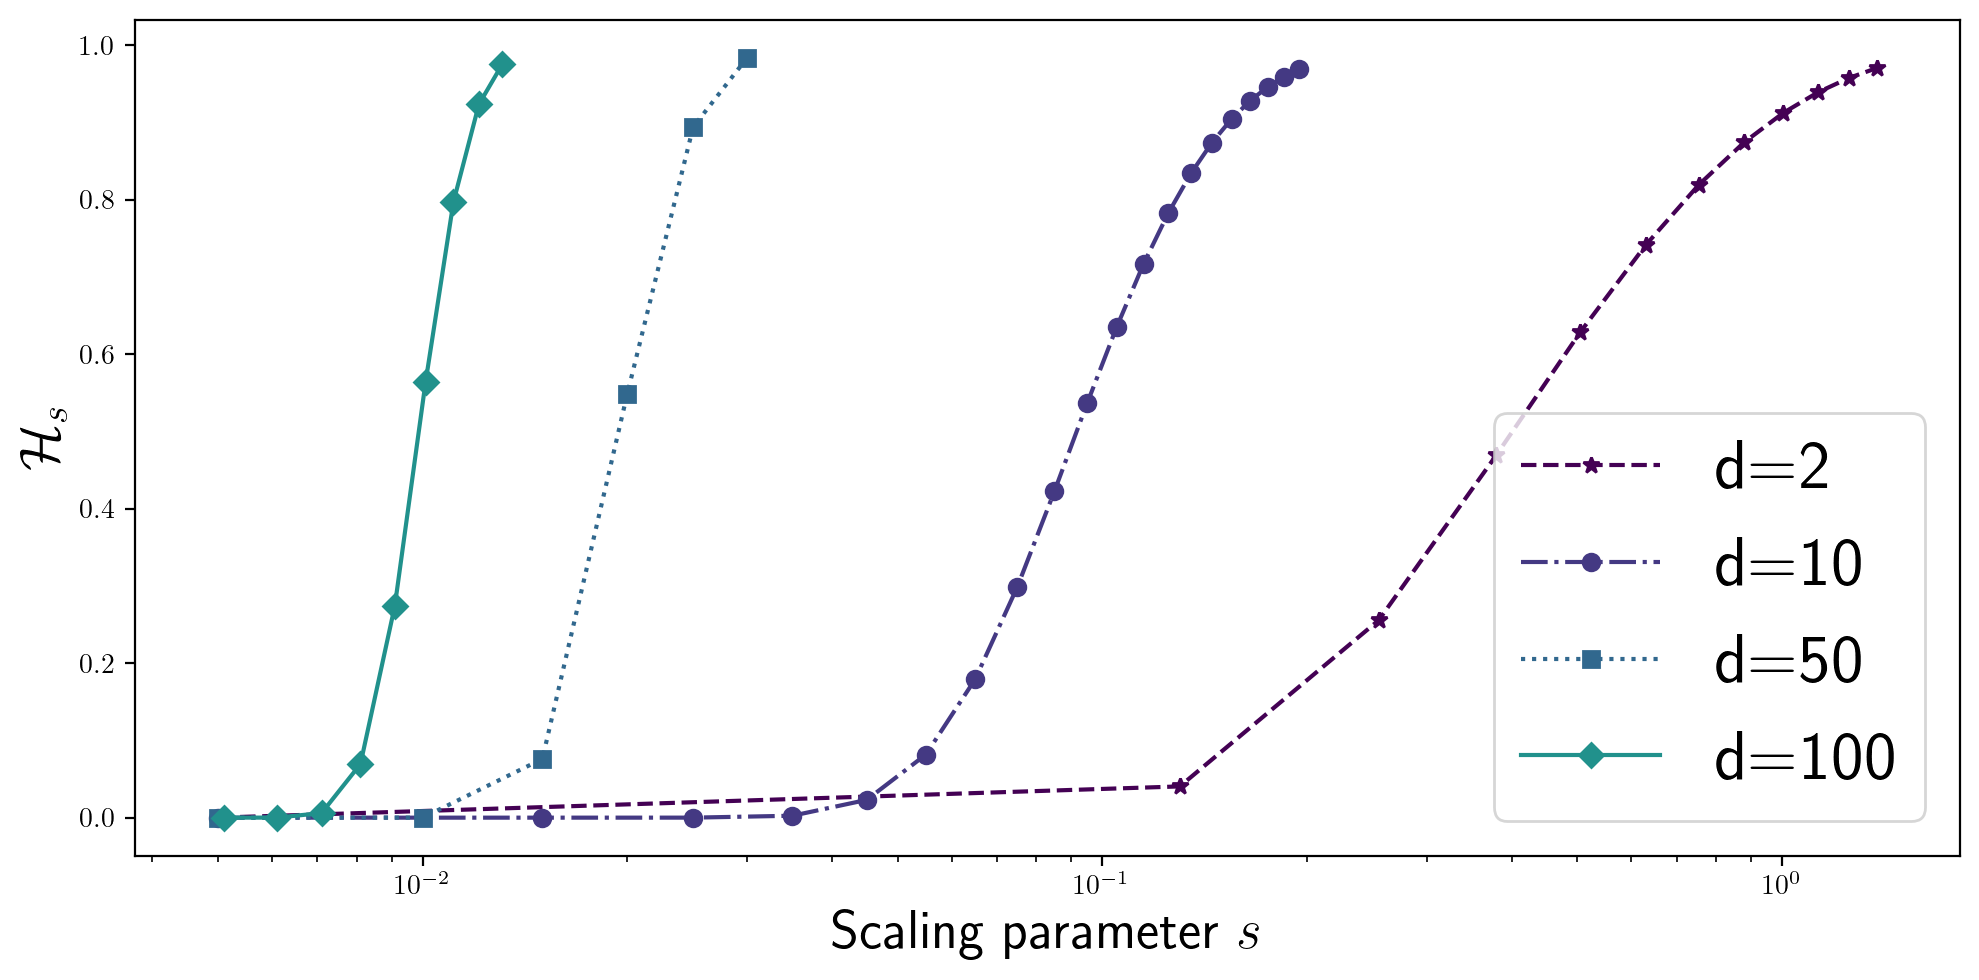

In [8]:
f , ax = plt.subplots(figsize=(10, 5),dpi=200)
for i,d in enumerate(dims):
    ax.plot(H_s[d][:,0], H_s[d][:,1], marker=marks[i], linestyle=linestyles[i], color=colors[i], label=r'd={}'.format(d));
# xticks_locations = ax.get_xticks()
# ax.set_xticks(xticks_locations, labels=[f'{x[:4]}' for x in H_s[:,0]]);
# yticks_locations = ax.get_yticks()
# ax.set_yticks(yticks_locations, labels=[f'{float(x):.5f}' for x in H_s[:,1]]);
plt.xlabel(r'Scaling parameter $s$', fontproperties=font)
plt.ylabel(r'$\mathcal{{H}}_s$', fontproperties=font)
# plt.title(r'$\mathcal{{H}}_s$', fontproperties=font)
plt.xscale('log');
ax.legend(prop={'size': 25}, loc='lower right', bbox_to_anchor=(1, 0))
plt.tight_layout();

f.savefig(f'H_s.pdf',format="pdf",dpi=600)

In [44]:
path_times_woc = f"path_times_WoC.json"
path_times_wohb = f"path_times_WoHB.json"
with open(path_times_woc, 'r') as json_file:
    # Use json.load() to convert the file content into a Python dictionary
    times_woc = json.load(json_file)
with open(path_times_wohb, 'r') as json_file:
    # Use json.load() to convert the file content into a Python dictionary
    times_wohb = json.load(json_file)
times_wohb

[5.7311878025785985,
 8.719328886178495,
 9.531126827887425,
 9.835343945713237,
 9.936465718905776,
 9.980365565241826,
 9.99418038080186,
 9.99792602787658,
 9.999348229657109,
 9.99977546353283,
 9.999920863987333,
 6.780791633658468,
 8.624756978978928,
 9.602304355870244,
 9.849970312838542,
 9.948121650384245,
 9.980814361281135,
 9.991697833927558,
 9.996070131518449,
 9.99859379766895,
 9.999485469444997,
 9.999781101647342,
 9.999912806667076,
 6.354775112364463,
 9.021453568443238,
 9.655284556557033,
 9.851647584534891,
 9.943595789789967,
 9.974358579400118,
 9.990577730845596,
 9.996551939615667,
 9.999014906254835,
 9.999634551362721,
 9.999871675626226,
 9.999951965088558,
 6.058849162603204,
 8.151719014024323,
 9.228085713687685,
 9.663419961552254,
 9.835270990546208,
 9.929532528723627,
 9.971444739787984,
 9.990584853433685,
 9.997273292900694,
 9.99915557074513,
 9.999757089117146,
 9.999904233751497,
 4.667727862198998,
 7.950493922127862,
 9.181223403100732,
 9.7

In [42]:
cols = []
for k,v in times_woc.items():
    for k1,v1 in v.items():
        for t in v1:
            cols.append([k,k1,t])
for k,v in times_wohb.items():
    print(v)
    for t in v:
        cols.append([k,'wohb',t])
df_times = pd.DataFrame(cols,columns=['dim','s','time'],dtype=np.float32)
df_times.head()

AttributeError: 'list' object has no attribute 'items'

In [11]:
df_times.describe()

,dim,s,time
count,94286.000000,94286.000000,94286.000000
mean,20.229876,0.353587,8.780374
std,27.938774,0.366904,1.863966
min,2.000000,0.007300,0.060030
25%,2.000000,0.090000,8.196101
50%,10.000000,0.150000,9.801950
75%,10.000000,0.800000,9.998392
max,100.000000,1.000000,10.000000


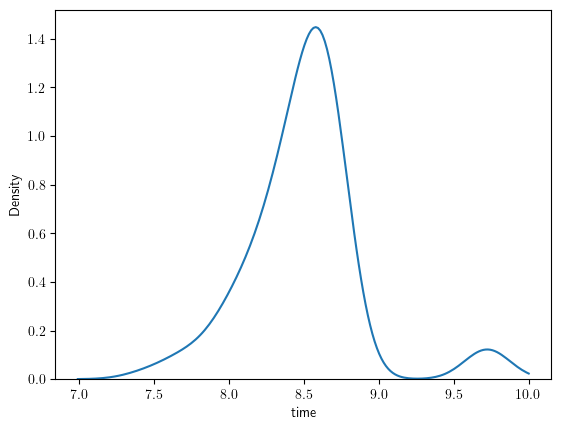

In [12]:
sns.kdeplot(df_times[(df_times['dim']==100)&(df_times['s']<=0.009)],x='time',clip=(0,10),common_norm=False);

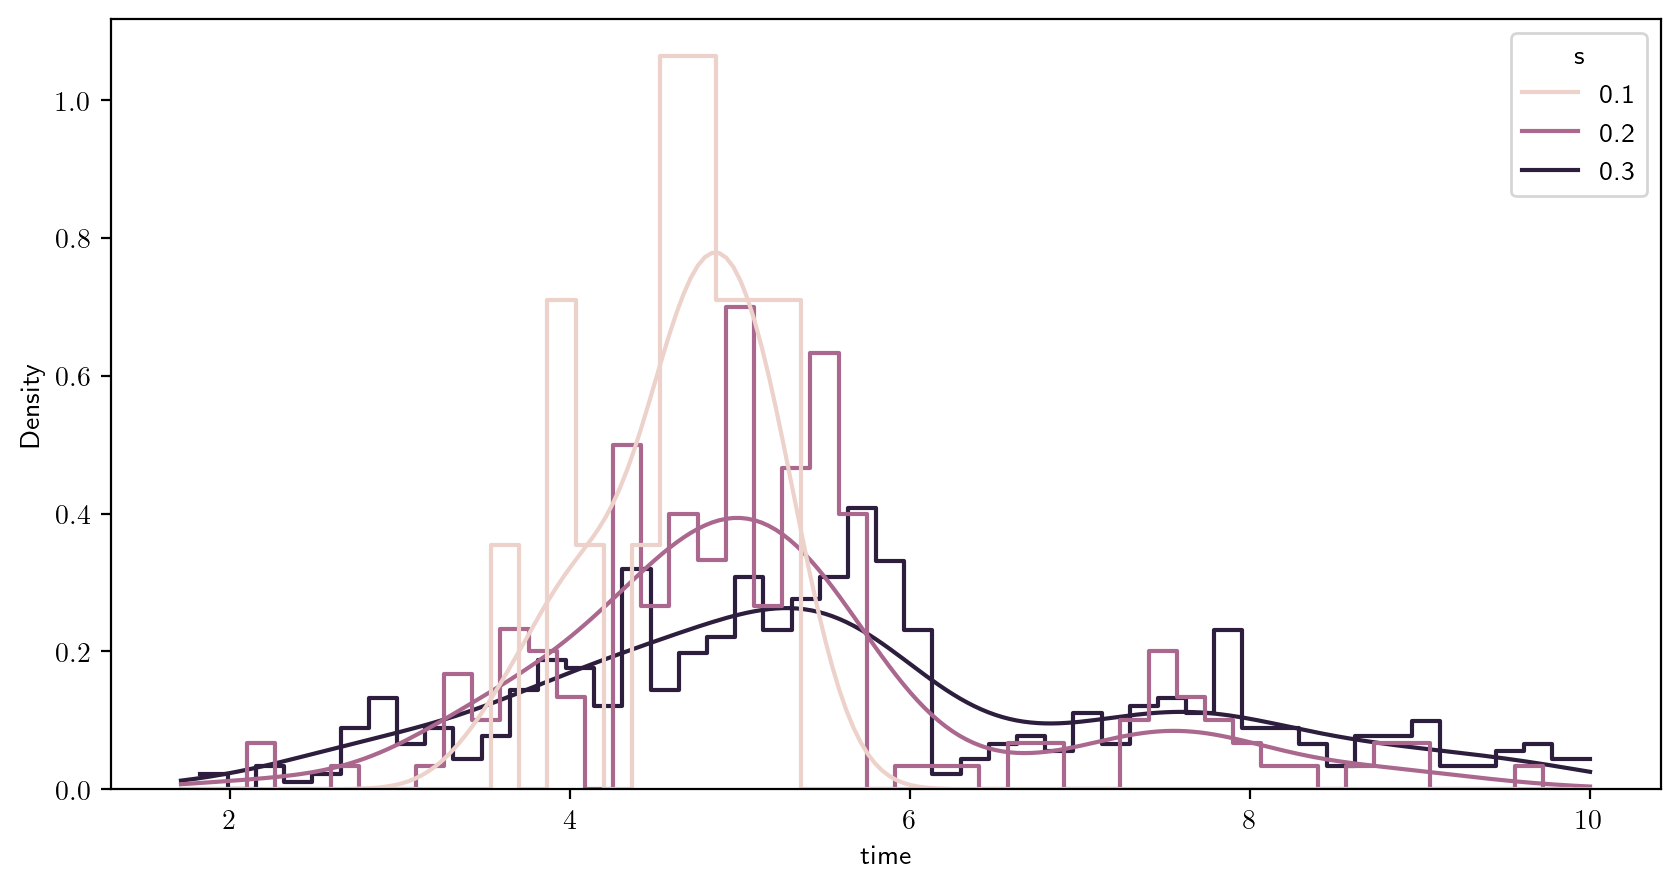

In [111]:
f,ax = plt.subplots(1,1,figsize=(10,5),dpi=200)
sns.histplot(ax=ax, data=df_times[(df_times['dim']==2)&(df_times['s']<=0.3)], x='time', hue='s',  kde=True, bins=50, common_norm=False,stat = 'density', multiple = 'dodge', element="step", fill = False);

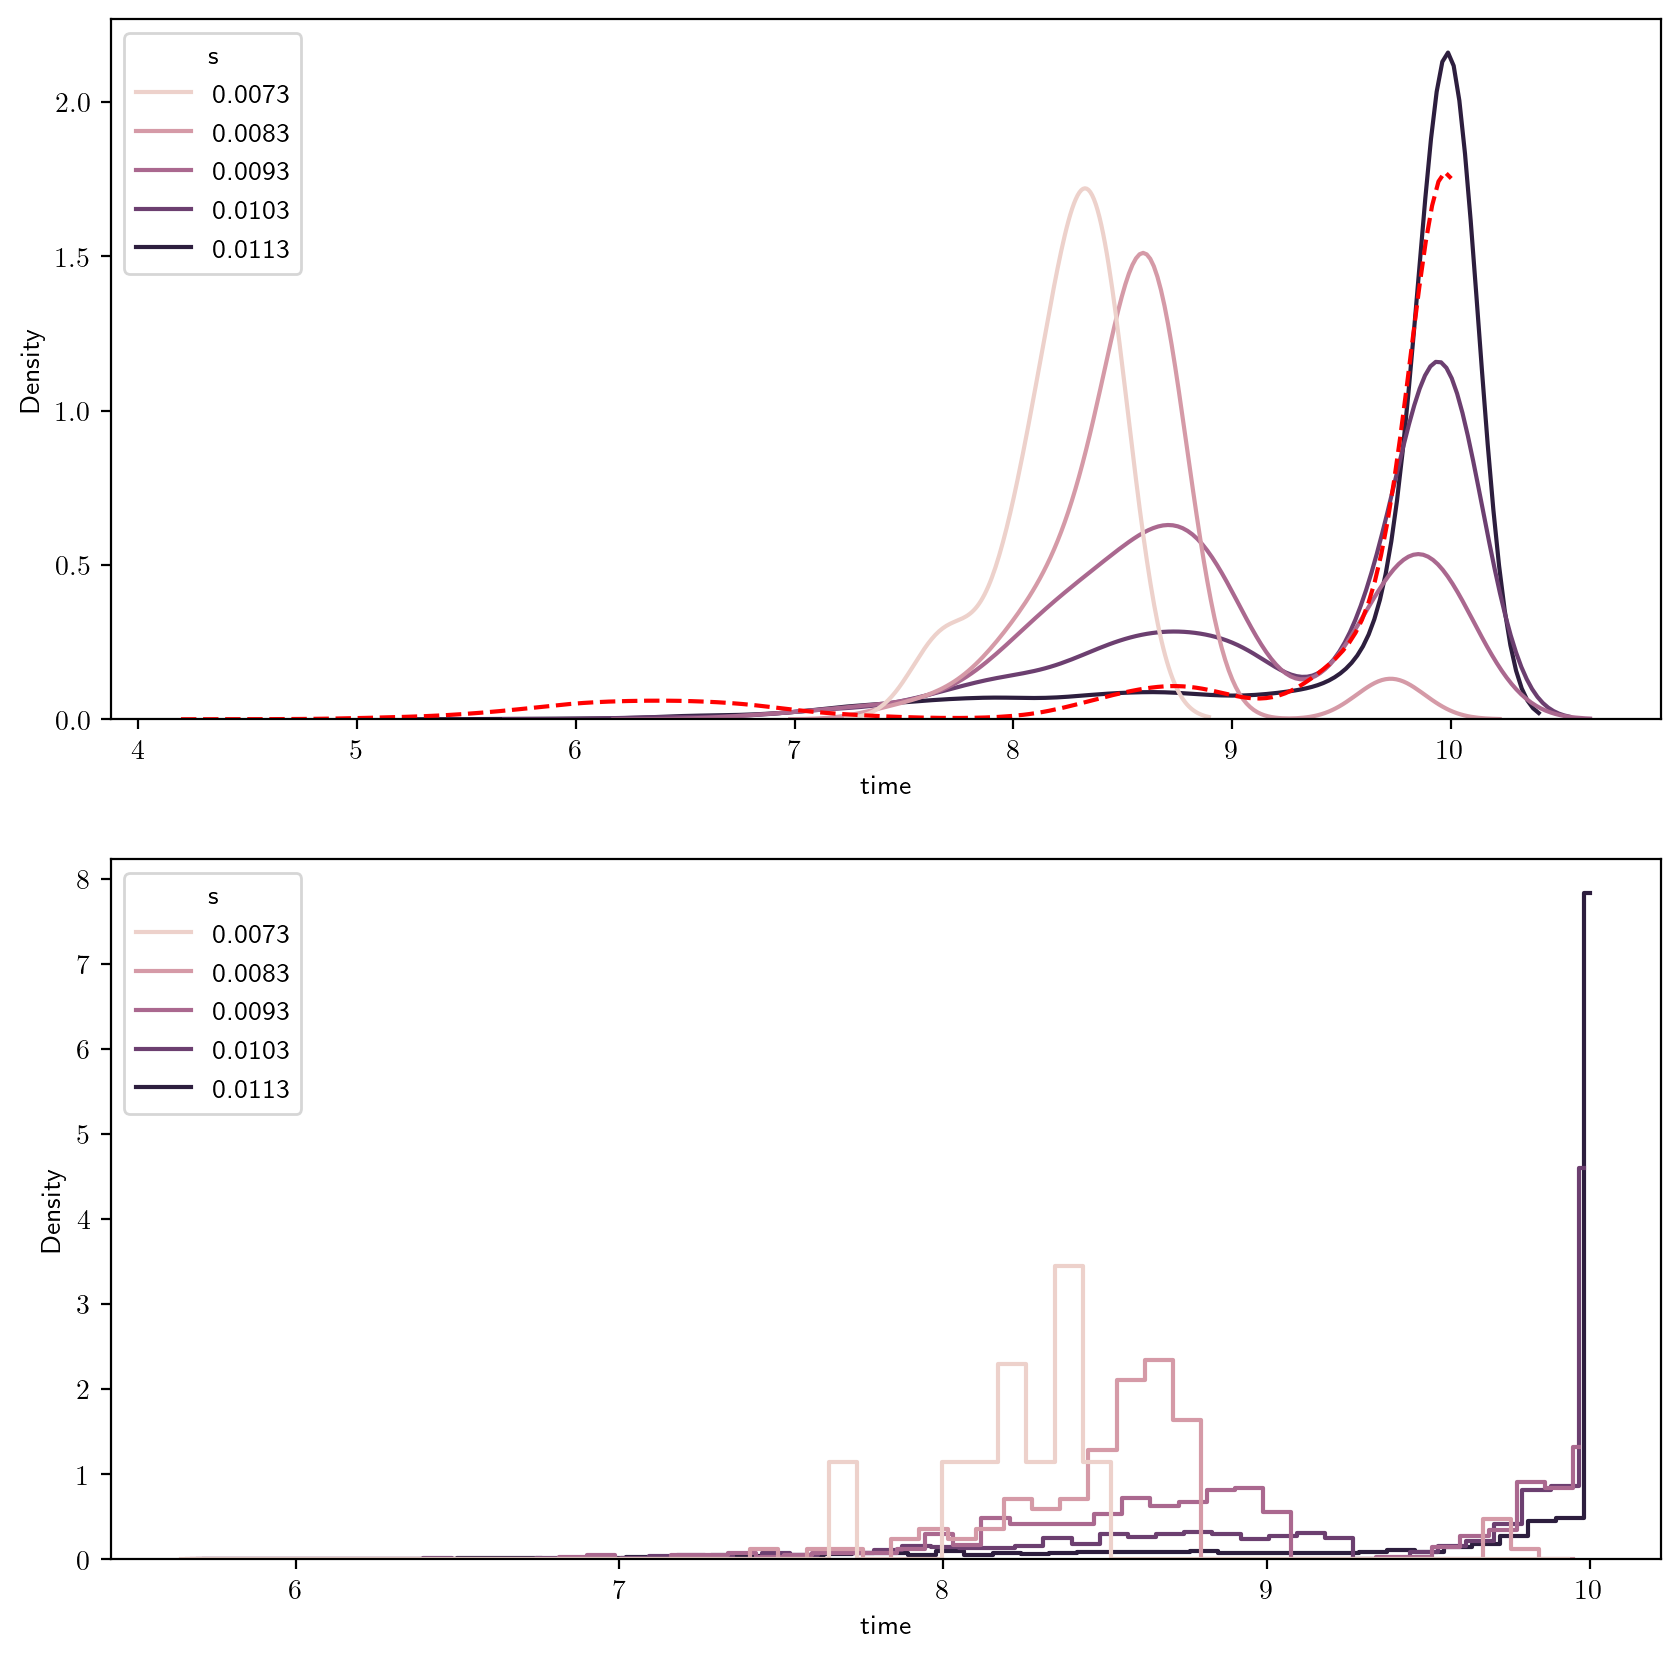

In [39]:
f, ax = plt.subplots(2,1,figsize=(10,10), dpi=200)
k = '100'
# for s,t in times_woc[k].items():
#     sns.kdeplot(times_woc[k][s], clip=(0, 10), label=f"WoC, d={k},s={s:.5}",common_norm=True, ax=ax[0]);
sns.kdeplot(ax=ax[0], data=df_times[(df_times['dim']==100)&(df_times['s']<=1)], x='time', hue='s', common_norm=False);
sns.kdeplot(times_wohb, color='r', clip=(0, 10), label='WoHB', ax=ax[0],linestyle='dashed');
# ax[0].legend(prop={'size': 10}, loc='upper left', bbox_to_anchor=(0, 1))
sns.histplot(ax=ax[1], data=df_times[(df_times['dim']==100)&(df_times['s']<=1)], x='time', hue='s',  kde=False, bins=50, common_bins=True, common_norm=False,stat = 'density', multiple = 'dodge', element="step", fill = False);
# sns.histplot(times_wohb,  alpha=0.2, color='r', label='WoHB', ax=ax[1],common_norm=False,bins=50,stat = 'density', multiple = 'dodge', element="step", fill = False);
# ax[1].legend(prop={'size': 10}, loc='upper left', bbox_to_anchor=(0, 1));

In [113]:
times_woc['10']['0.04']

[6.618202776855442, 6.144952078199419, 6.416017059922084, 6.292867288111434]